In [1]:
# 量子コンピュータの頭の中(初版/Qiskit v1.3)
# ch7.6 : 実行結果を量子回路の可視化
# リスト7.8 ～ 7.14
# ---
# IBM Quantum LabのJupyterLab実行環境は廃止されているため利用できない。
# テキストのリスト7.3～7.13はIBM Quantum Lab上でのシミュレータ実行のため、
# Qiskit primitivesをローカルPCのシミュレータで実行するためのコードに改修した。

# リスト7.1:ノートブックにあらかじめ入力されたコード
# Importing standard Qiskit libralies
from qiskit import QuantumCircuit
#from qiskit_ibm_runtime import Sampler, Estimator, QiskitRuntimeService         # 実機用コードのためコメントアウト
#from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager  # 実機用コードのためコメントアウト
from qiskit.primitives import StatevectorSampler           # シミュレータ実行のために必要
from qiskit.visualization import *                         # ヒストグラム等の表示で必要

In [2]:
#--- リスト7.2:ソフトウェアのバージョンを確認
import qiskit
qiskit.__version__

'1.3.1'

In [3]:
#--- リスト7.3:量子回路の作成
# 量子回路の初期化
circuit = QuantumCircuit(2)

# 量子回路の組み立て
circuit.h(0)    # アダマール行列を適用
circuit.cx(0,1) # CNOTを適用

# 測定
circuit.measure_all()

In [4]:
#--- リスト7.4:実行と結果取得
#--- リスト7.5:実行結果(実行結果は本ブロックの実行結果として出力される)

# 実行と結果取得
sampler = StatevectorSampler()                  # バックエンドを指定  
job = sampler.run([circuit])                    # 量子プログラムを実行
result = job.result()                           # PrimitiveResult形式の結果を取得
print(result[0].data.meas.get_counts())         # 結果をテキスト表示:measure_all()の場合、'meas'で結果を取得

{'11': 502, '00': 522}


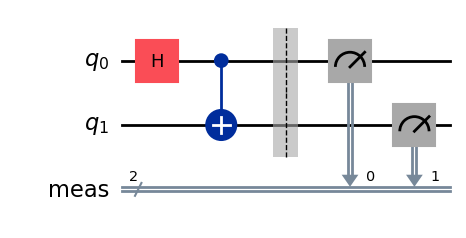

In [5]:
#--- リスト7.10:量子回路を描画
circuit.draw(output="mpl")


In [6]:
# Qiskitバージョン情報
import qiskit
print(f'qiskit version : {qiskit.__version__}')

# Pythonおよび実行環境情報
import sys, platform
print(f'python version : {sys.version}')
print(f'platform : {platform.uname()}')

qiskit version : 1.3.1
python version : 3.12.8 (main, Dec 18 2024, 17:27:54) [GCC 7.5.0]
platform : uname_result(system='Linux', node='wsl2suseLeap', release='5.15.167.4-microsoft-standard-WSL2', version='#1 SMP Tue Nov 5 00:21:55 UTC 2024', machine='x86_64')
